In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

In [35]:
df = pd.read_csv("run_results.csv")

In [36]:
df.describe()

,d_model,model_depth,head_dimension,n_heads,d_ffn,vocab_size,n_params_embedding,n_params_encoder,n_params_decoder,n_params_mha,...,attention_weight_matrix_lr,attention_bias_lr,w_ffn_in_lr,w_ffn_out_lr,bias_lr,unembedding_matrix_lr,final_loss,best_loss,training_wall_time,rng_seed
count,2023.000000,2023.0,2023.000000,2023.000000,2023.000000,2023.0,2.023000e+03,2.023000e+03,2.023000e+03,2.023000e+03,...,2.023000e+03,2023.000000,2.023000e+03,2.023000e+03,2023.000000,2.023000e+03,2023.000000,2023.000000,2023.000000,2023.000000
mean,283.254572,24.0,82.791893,4.476520,1133.018290,32128.0,9.100403e+06,9.100403e+06,9.100403e+06,1.470586e+05,...,1.932061e-04,0.027362,1.932061e-04,4.830152e-05,0.027362,1.932061e-04,6.030212,5.207196,21276.421718,1.723183
std,258.570195,0.0,44.089152,5.688529,1034.280782,0.0,8.307343e+06,8.307343e+06,8.307343e+06,2.641525e+05,...,3.547733e-04,0.038415,3.547733e-04,8.869333e-05,0.038415,3.547733e-04,20.361407,18.262852,31660.861716,8.332987
min,32.000000,24.0,32.000000,1.000000,128.000000,32128.0,1.028096e+06,1.028096e+06,1.028096e+06,1.024000e+03,...,9.536743e-07,0.000977,9.536743e-07,2.384186e-07,0.000977,9.536743e-07,2.975324,2.975324,114.124368,0.000000
25%,128.000000,24.0,32.000000,1.000000,512.000000,32128.0,4.112384e+06,4.112384e+06,4.112384e+06,1.638400e+04,...,1.779982e-05,0.003906,1.779982e-05,4.449955e-06,0.003906,1.779982e-05,3.510009,3.509797,834.181332,0.000000
50%,256.000000,24.0,64.000000,2.000000,1024.000000,32128.0,8.224768e+06,8.224768e+06,8.224768e+06,6.553600e+04,...,5.651091e-05,0.013602,5.651091e-05,1.412773e-05,0.013602,5.651091e-05,4.229978,4.112712,10855.269162,0.000000
75%,512.000000,24.0,128.000000,4.000000,2048.000000,32128.0,1.644954e+07,1.644954e+07,1.644954e+07,2.621440e+05,...,1.937745e-04,0.039373,1.937745e-04,4.844364e-05,0.039373,1.937745e-04,5.208618,4.770609,26970.843696,0.000000
max,1024.000000,24.0,128.000000,32.000000,4096.000000,32128.0,3.289907e+07,3.289907e+07,3.289907e+07,1.048576e+06,...,2.278377e-03,0.250000,2.278377e-03,5.695943e-04,0.250000,2.278377e-03,374.245812,374.018747,169222.904452,42.000000


In [37]:
print(df.columns)

Index(['d_model', 'model_depth', 'head_dimension', 'n_heads', 'd_ffn',
       'vocab_size', 'n_params_embedding', 'n_params_encoder',
       'n_params_decoder', 'n_params_mha', 'n_params_rms_norm', 'n_params_ffn',
       'n_params_transformer_block', 'n_parameters', 'base_lr', 'init_stddev',
       'absolute_init_stddev', 'max_lr', 'lr_schedule_name', 'optim_name',
       'optim_beta1', 'optim_beta2', 'optim_eps', 'weight_decay',
       'n_training_tokens', 'tokens_per_global_batch', 'batch_size',
       'sequence_len', 'n_pretrain_step', 'n_warmup_step',
       'embedding_matrix_lr', 'attention_weight_matrix_lr',
       'attention_bias_lr', 'w_ffn_in_lr', 'w_ffn_out_lr', 'bias_lr',
       'unembedding_matrix_lr', 'run_id', 'run_folder_path',
       'run_losses_df_path', 'final_loss', 'best_loss', 'training_wall_time',
       'lr_schedule_mode', 'rng_seed'],
      dtype='object')


In [38]:
df = df[df['head_dimension'] == 32]

In [39]:
print(df['n_pretrain_step'].unique())
print(df['n_training_tokens'].unique())
print(df['n_parameters'].unique())
print(df['lr_schedule_mode'].unique())

[  696.  1526. 89208.  3591.  9342. 27324.]
[4.55628800e+07 9.99731200e+07 5.84630272e+09 2.35335680e+08
 6.12229120e+08 1.79068928e+09]
[  2278144   4998656  11766784  30611456  89534464 292315136]
['relative' 'clipping']


In [40]:
# calculate effective learning rate (base_lr * sqrt(n_training_tokens))
df['effective_lr'] = df['base_lr'] * np.sqrt(df['n_training_tokens'])

In [41]:
# create column that states whether model was trained to full length or not
df['full_length_training'] = df['n_training_tokens'] == 5.84630272e+09

# split into relative and not relative df
df_relative = df[df['lr_schedule_mode'] == 'relative']
df_not_relative = df[df['lr_schedule_mode'] != "relative"]

# take best runs for each learning rate (different initialization variances)
df_best_runs_not_relative = (
    df_not_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["base_lr", "d_model", "full_length_training"], keep="first")
)
df_best_runs_relative = (
    df_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["base_lr", "d_model", "full_length_training"], keep="first")
)

# take optimal lr for optimum plotting
df_optimal_lrs_not_relative = (
    df_best_runs_not_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["d_model", "full_length_training"], keep="first")
)
df_optimal_lrs_relative = (
    df_best_runs_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["d_model", "full_length_training"], keep="first")
)

In [42]:
# plotting helper function for legend
def two_row_legend(ax, y_label=1.15, y_swatch=1.08, swatch_halfwidth=0.02):
    handles, labels = ax.get_legend_handles_labels()
    n = len(labels)
    xs = np.linspace(1/(2*n), 1 - 1/(2*n), n)  # evenly spaced centers

    for x, h, l in zip(xs, handles, labels):
        # label text (top row)
        ax.annotate(
            l, xy=(x, y_label), xycoords='axes fraction',
            ha='center', va='bottom', clip_on=False
        )
        # color/linestyle swatch (bottom row)
        color = h.get_color()
        ls = h.get_linestyle()
        lw = h.get_linewidth()
        ax.plot(
            [x - swatch_halfwidth, x + swatch_halfwidth],
            [y_swatch, y_swatch],
            transform=ax.transAxes,
            color=color, linestyle=ls, linewidth=lw,
            clip_on=False, solid_capstyle='butt'
        )

# usage
# two_row_legend(ax)
# fig.subplots_adjust(top=0.8)  # leave room above the axes

In [43]:
import numpy as np
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import Bbox

def two_row_legend(ax, y_label=1.16, y_swatch=1.08, swatch_halfwidth=0.05,
                    pad_x=0.02, pad_y=0.03, x_offset=0.0):
    fig = ax.figure
    handles, labels = ax.get_legend_handles_labels()
    n = len(labels)
    xs = np.linspace(1/(2*n), 1 - 1/(2*n), n) + x_offset

    artists = []

    for x, h, l in zip(xs, handles, labels):
        color = h.get_color()
        ls = h.get_linestyle()
        lw = h.get_linewidth()
        marker = h.get_marker()
        mfc = h.get_markerfacecolor()
        mec = h.get_markeredgecolor()
        ms = h.get_markersize()

        txt = ax.annotate(
            l, xy=(x, y_label), xycoords='axes fraction',
            ha='center', va='bottom', clip_on=False,
            zorder=5
        )
        artists.append(txt)

        line, = ax.plot(
            [x - swatch_halfwidth, x, x + swatch_halfwidth],
            [y_swatch, y_swatch, y_swatch],
            transform=ax.transAxes,
            color=color, linestyle=ls, linewidth=lw,
            marker=marker, markevery=[1],
            markerfacecolor=mfc, markeredgecolor=mec, markersize=ms,
            clip_on=False, solid_capstyle='butt', zorder=5
        )
        artists.append(line)

    # --- compute bounding box around everything we just drew ---
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    bboxes = [a.get_window_extent(renderer) for a in artists]
    full_bbox = Bbox.union(bboxes)

    # --- NEW: separate absolute x/y padding, in fractions of figure size ---
    pad_x_px = pad_x * fig.bbox.width
    pad_y_px = pad_y * fig.bbox.height

    full_bbox = Bbox.from_extents(
        full_bbox.x0 - pad_x_px, full_bbox.y0 - pad_y_px,
        full_bbox.x1 + pad_x_px, full_bbox.y1 + pad_y_px
    )
    # --- end new block ---

    inv = ax.transAxes.inverted()
    (x0, y0), (x1, y1) = inv.transform(full_bbox)

    box = FancyBboxPatch(
        (x0, y0), x1 - x0, y1 - y0,
        transform=ax.transAxes,
        boxstyle="round,pad=0,rounding_size=0.02",   # set to 0 since padding is handled above already
        facecolor='white', edgecolor='black', linewidth=0.8,
        zorder=4, clip_on=False
    )
    ax.add_patch(box)

# usage
# two_row_legend(ax)
# fig.subplots_adjust(top=0.8)

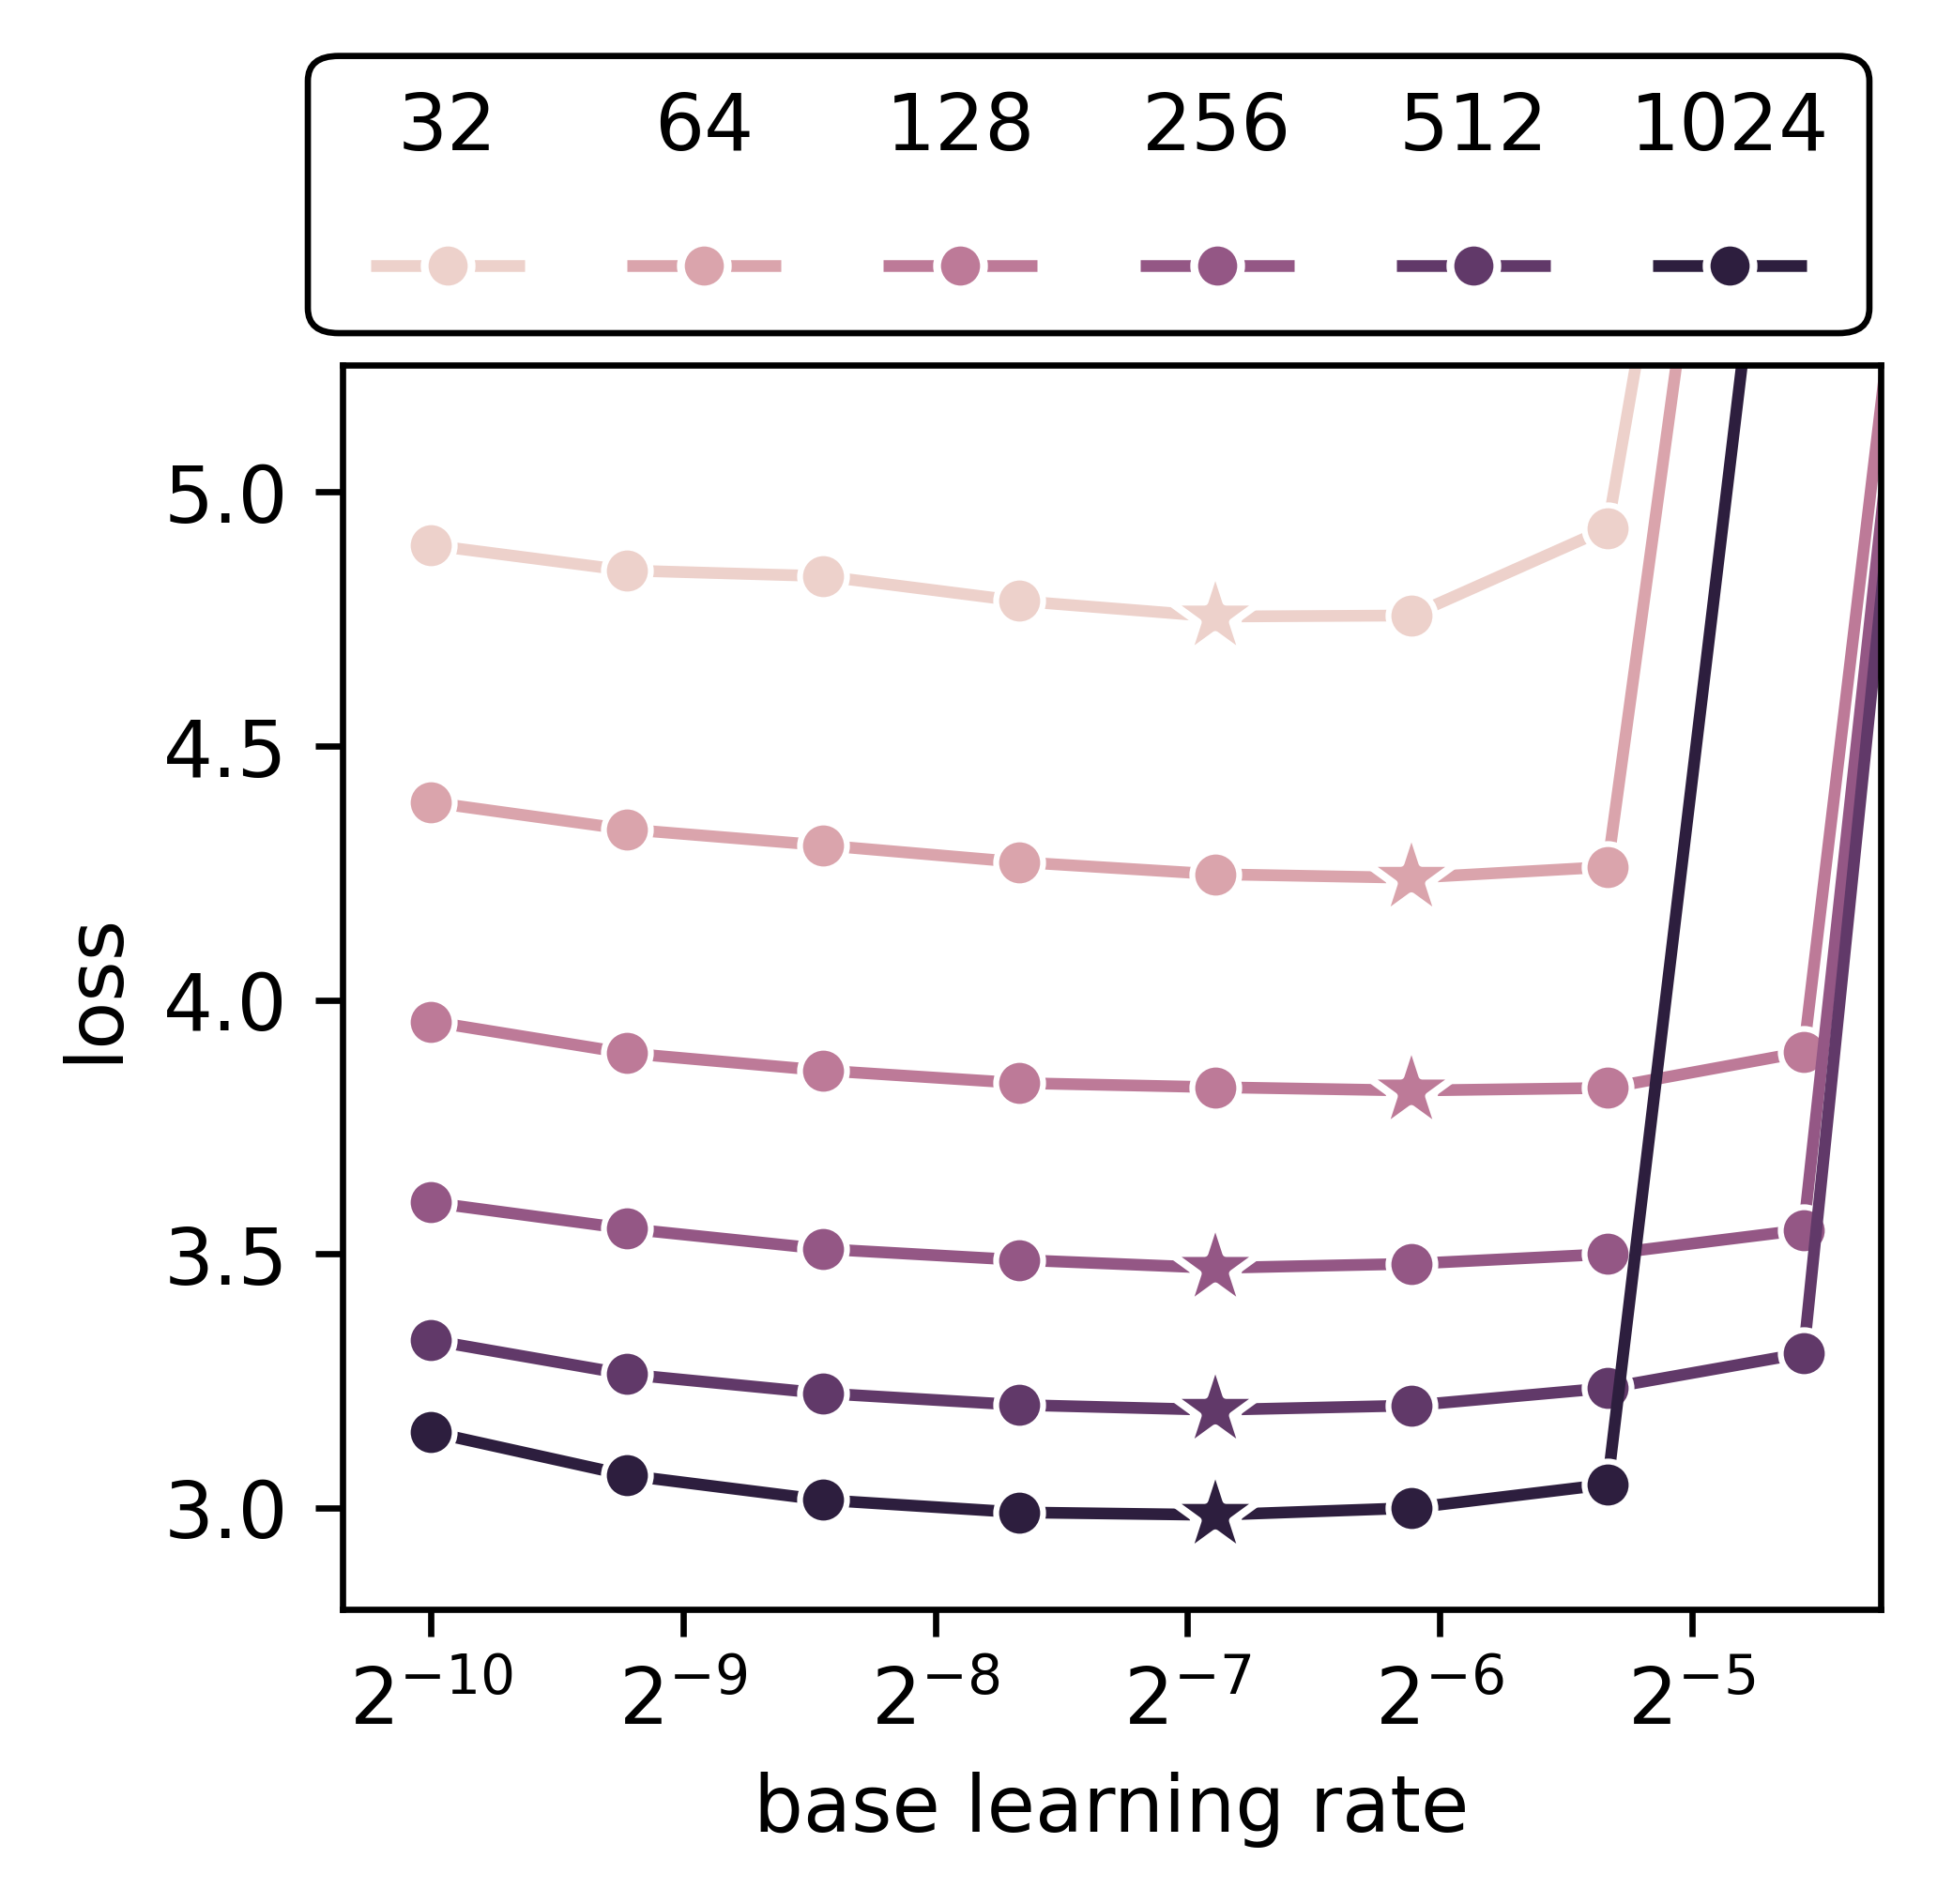

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

# final loss
sns.lineplot(df_best_runs_not_relative.query('full_length_training == True'),
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='o',
    zorder=1,
    )

sns.scatterplot(
    df_optimal_lrs_not_relative.query('full_length_training == True'),
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

ax.set_xscale('log', base=2)
ax.set_xlim(2**-10.35, 2**-4.25)
ax.set_ylim(2.8, 5.25)

two_row_legend(ax, x_offset=-0.015)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

ax.set_ylabel('loss')
ax.set_xlabel('base learning rate')
# ax.set_title("Loss vs optimal learning rate under muTransfer and full training")

plt.tight_layout()
plt.show()

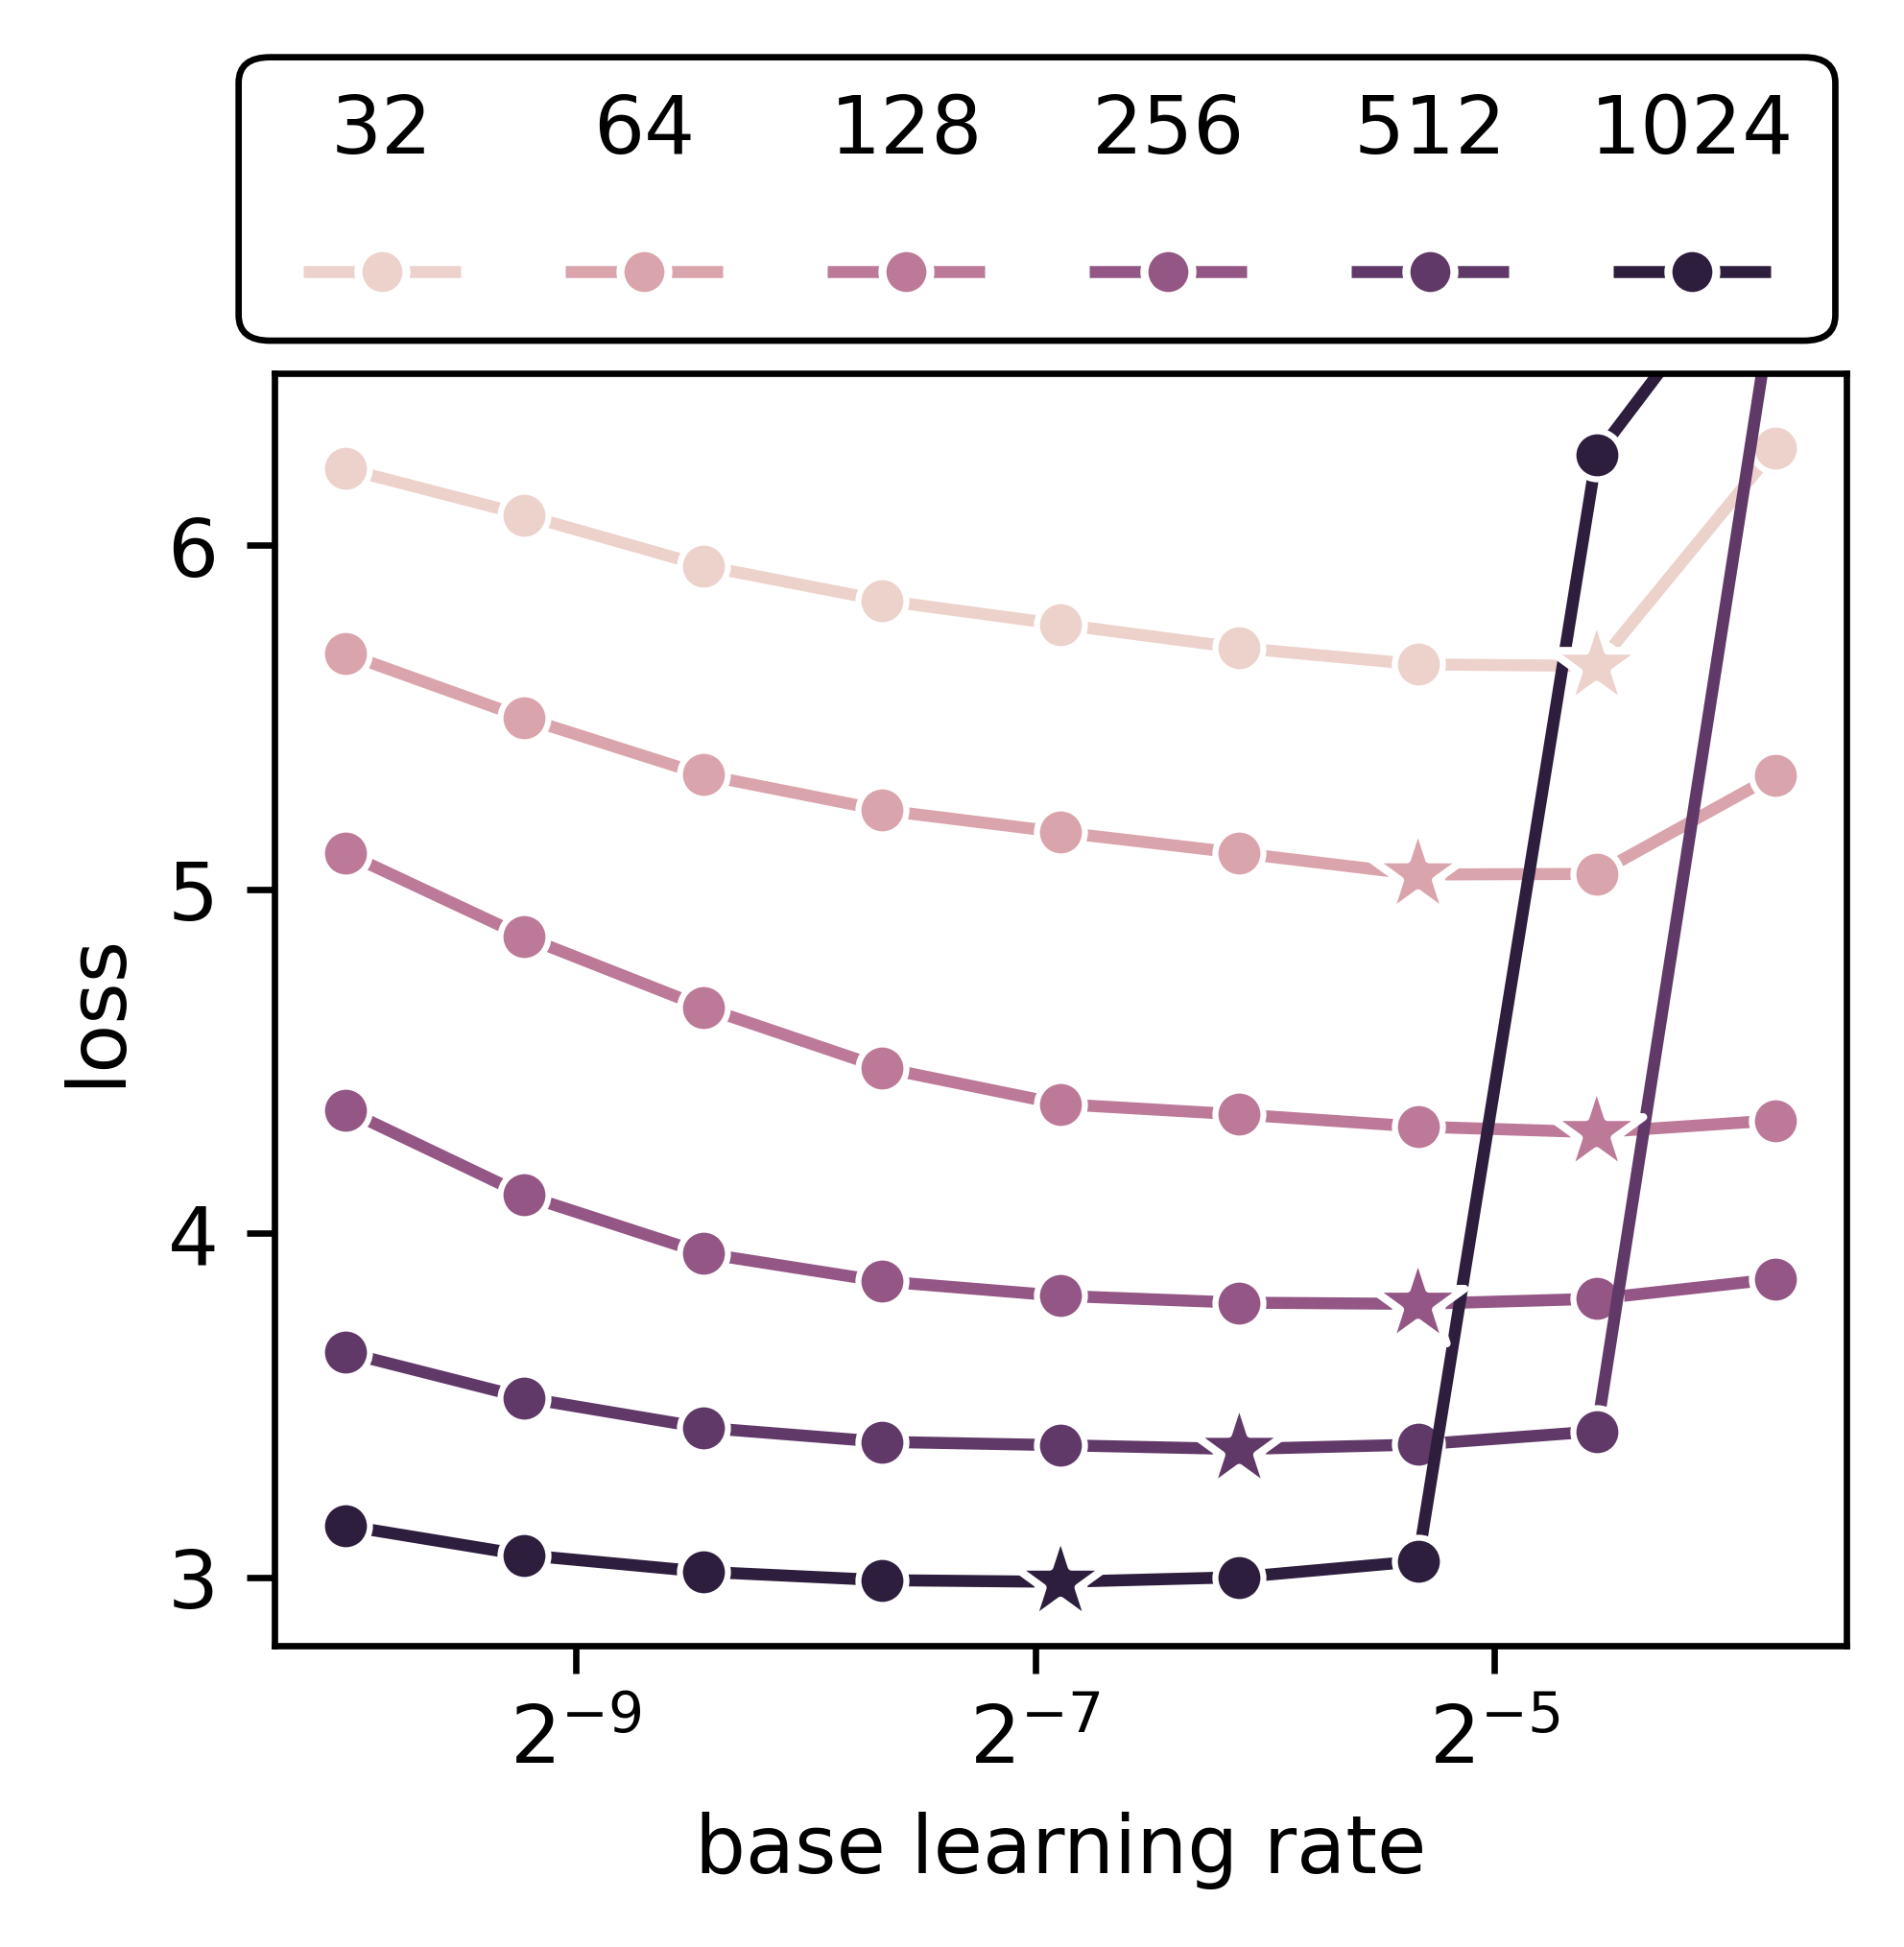

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

merged_run_df = pd.concat(
    [
        df_best_runs_not_relative.query("d_model == 1024"),
        df_best_runs_relative
    ]
)
merged_optimal_lr_df = pd.concat([
    df_optimal_lrs_not_relative.query('d_model == 1024'),
    df_optimal_lrs_relative
])

# final loss
sns.lineplot(merged_run_df,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='o',
    zorder=2,
    )

sns.scatterplot(
    merged_optimal_lr_df,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)



ax.set_xscale('log', base=2)
# ax.set_xlim(2**-10.2, 2**-3.55)
ax.set_ylim(2.8, 6.5)

# labels
ax.set_xlabel('base learning rate')
ax.set_ylabel('loss')

# legend
two_row_legend(ax, x_offset=-0.015)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

# ax.set_title("Loss vs optimal learning rate under muTransfer with relative lr schedule")

plt.tight_layout()
plt.show()

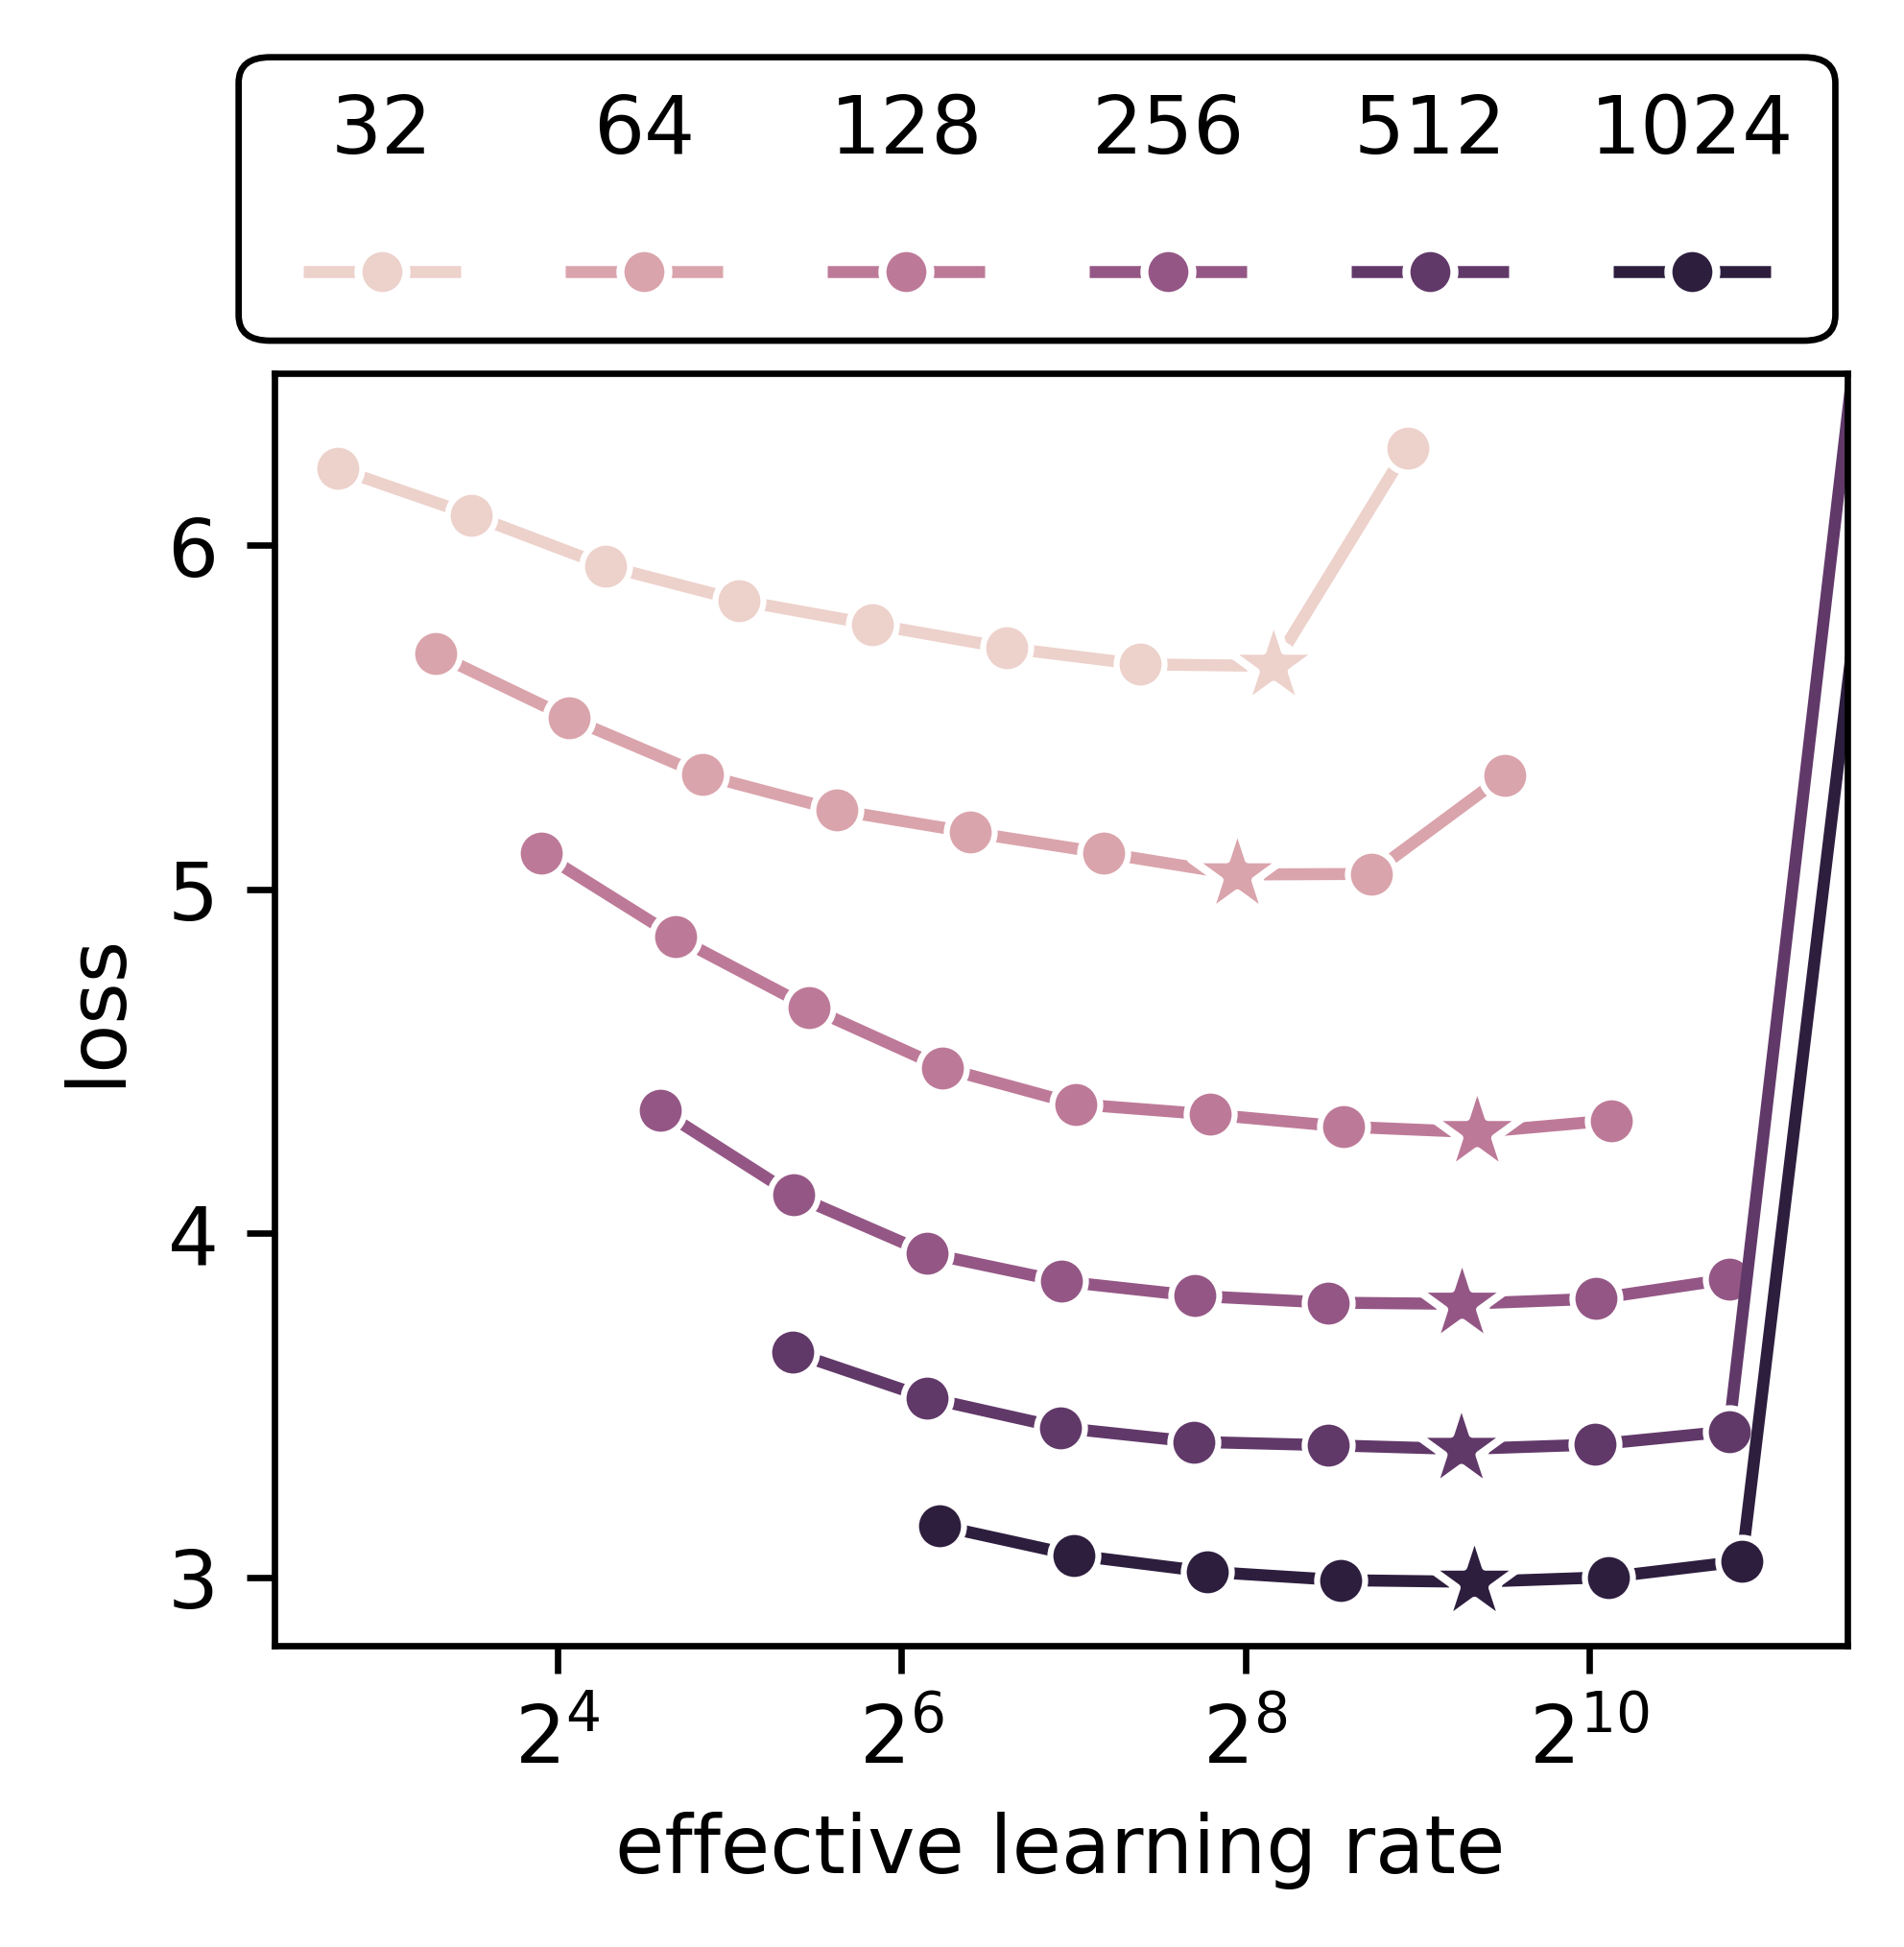

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

merged_run_df = pd.concat(
    [
        df_best_runs_not_relative.query("d_model == 1024"),
        df_best_runs_relative
    ]
)
merged_optimal_lr_df = pd.concat([
    df_optimal_lrs_not_relative.query('d_model == 1024'),
    df_optimal_lrs_relative
])

# final loss
sns.lineplot(merged_run_df,
    x="effective_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='o',
    zorder=2,
    )

sns.scatterplot(
    merged_optimal_lr_df,
    x='effective_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)



ax.set_xscale('log', base=2)
ax.set_xlim(2**2.35, 2**11.5)
ax.set_ylim(2.8, 6.5)

# labels
ax.set_xlabel('effective learning rate')
ax.set_ylabel('loss')

# legend
two_row_legend(ax, x_offset=-0.015)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

# ax.set_title("Loss vs optimal learning rate under muTransfer with relative lr schedule")

plt.tight_layout()
plt.show()

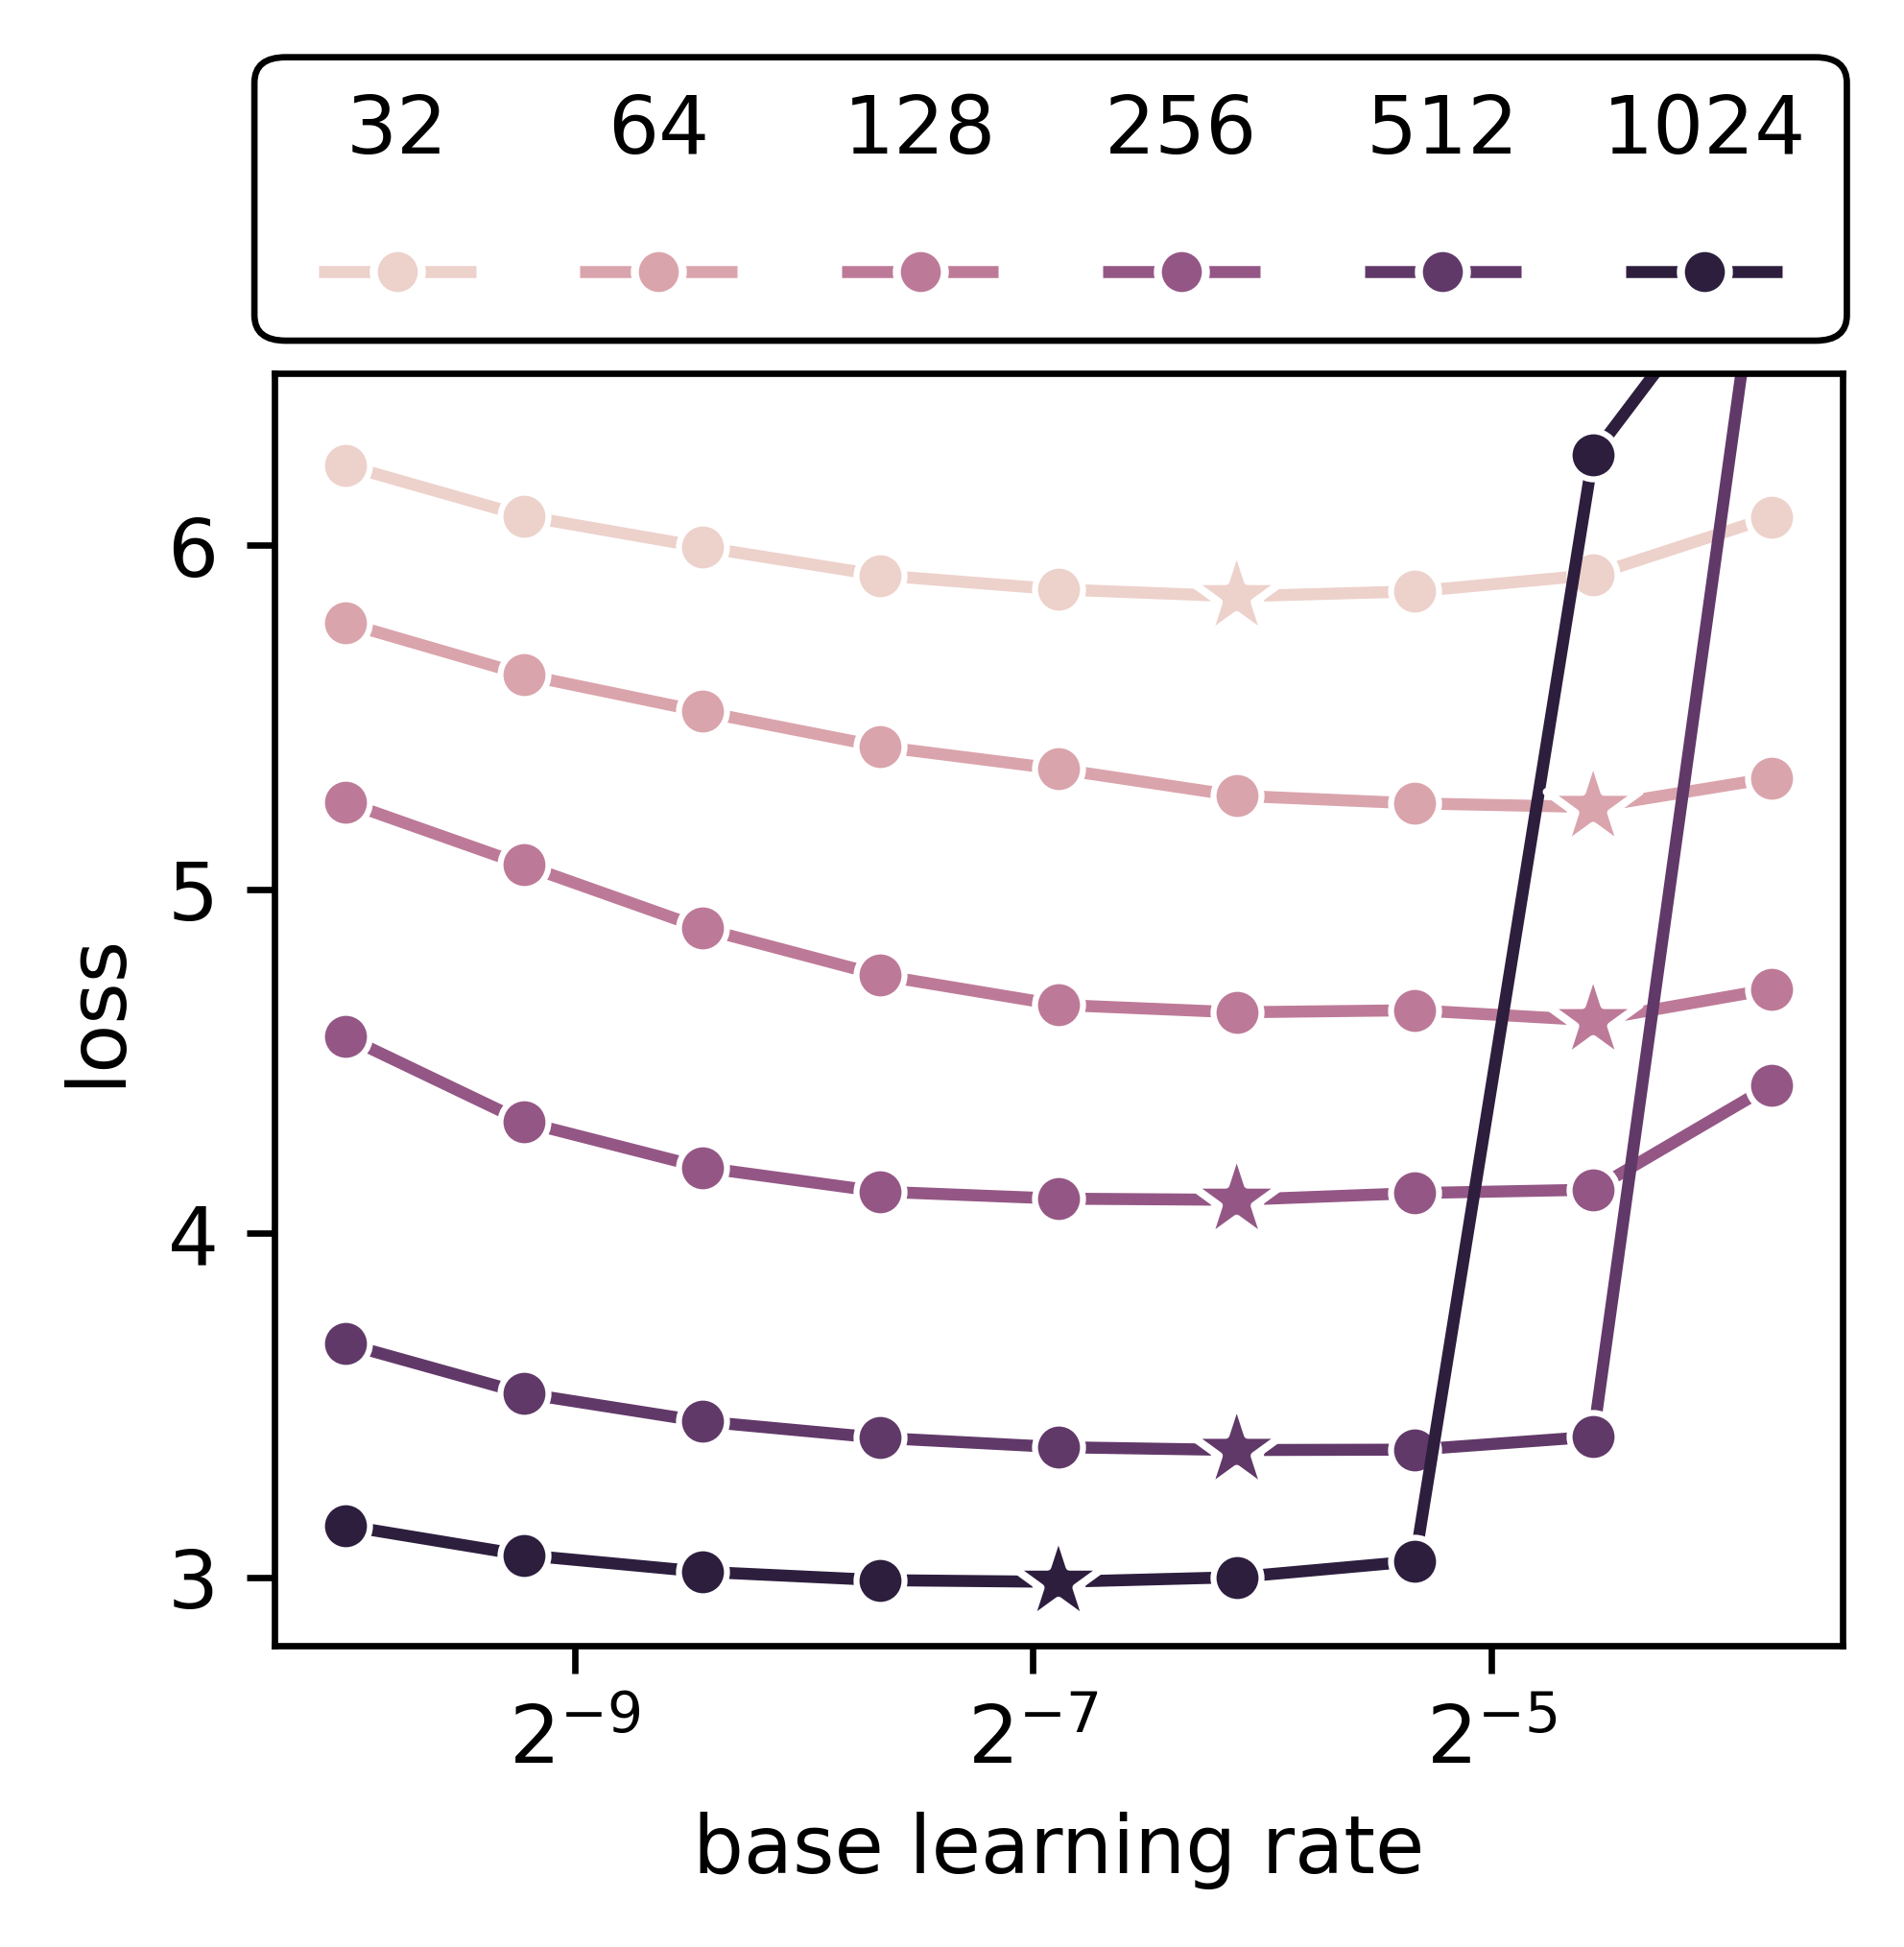

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

merged_run_df = pd.concat(
    [
        df_best_runs_not_relative.query("d_model == 1024"),
        df_best_runs_not_relative.query("full_length_training == False")
    ]
)
merged_optimal_lr_df = pd.concat([
    df_optimal_lrs_not_relative.query('d_model == 1024'),
    df_optimal_lrs_not_relative.query("full_length_training == False")
])


# final loss
sns.lineplot(merged_run_df,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='o',
    zorder=2,
    )

sns.scatterplot(
    merged_optimal_lr_df,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)


ax.set_xscale('log', base=2)
# ax.set_xlim(2**7, 2**11)
ax.set_ylim(2.8, 6.5)

# labels
ax.set_xlabel('base learning rate')
ax.set_ylabel('loss')

# legend
two_row_legend(ax, x_offset=-0.005)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

# ax.set_title("Loss vs optimal base learning rate under muTransfer without relative lr schedule")

plt.tight_layout()
plt.show()

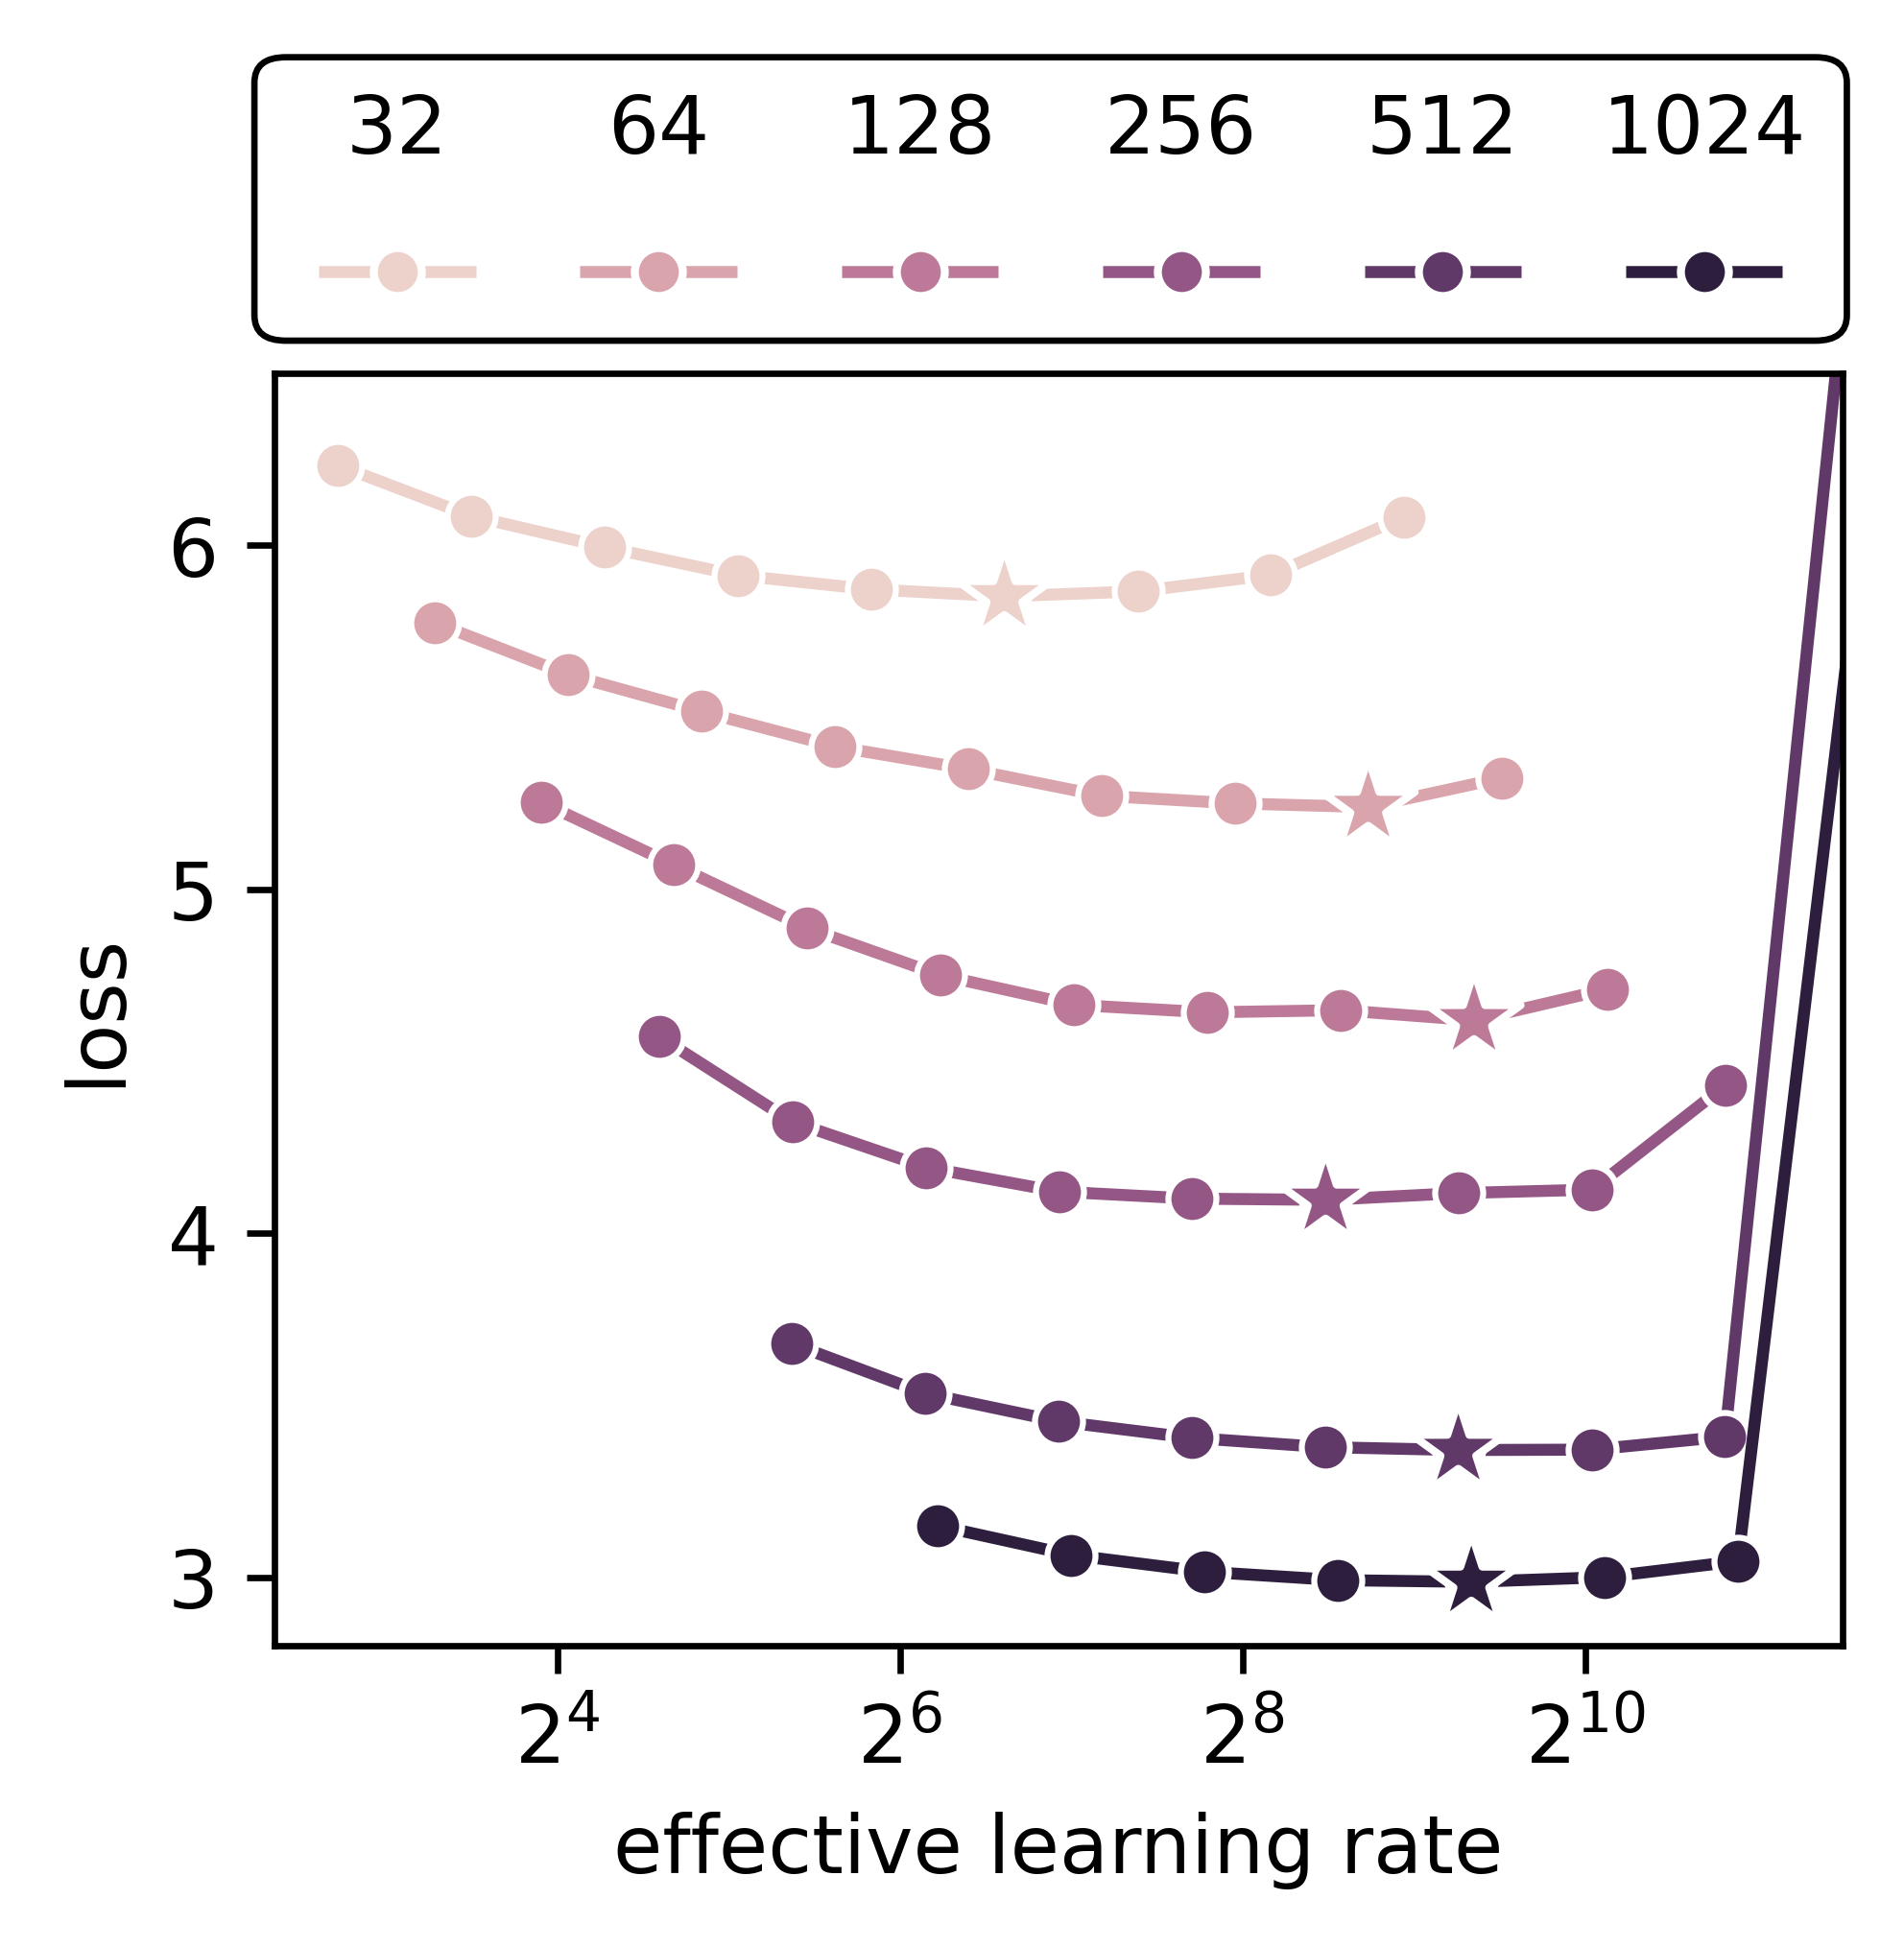

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

merged_run_df = pd.concat(
    [
        df_best_runs_not_relative.query("d_model == 1024"),
        df_best_runs_not_relative.query("full_length_training == False")
    ]
)
merged_optimal_lr_df = pd.concat([
    df_optimal_lrs_not_relative.query('d_model == 1024'),
    df_optimal_lrs_not_relative.query("full_length_training == False")
])


# final loss
sns.lineplot(merged_run_df,
    x="effective_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='o',
    zorder=2,
    )

sns.scatterplot(
    merged_optimal_lr_df,
    x='effective_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)


ax.set_xscale('log', base=2)
ax.set_xlim(2**2.35, 2**11.5)
ax.set_ylim(2.8, 6.5)

# labels
ax.set_xlabel('effective learning rate')
ax.set_ylabel('loss')

# legend
two_row_legend(ax, x_offset=-0.005)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

# ax.set_title("Loss vs optimal base learning rate under muTransfer without relative lr schedule")

plt.tight_layout()
plt.show()

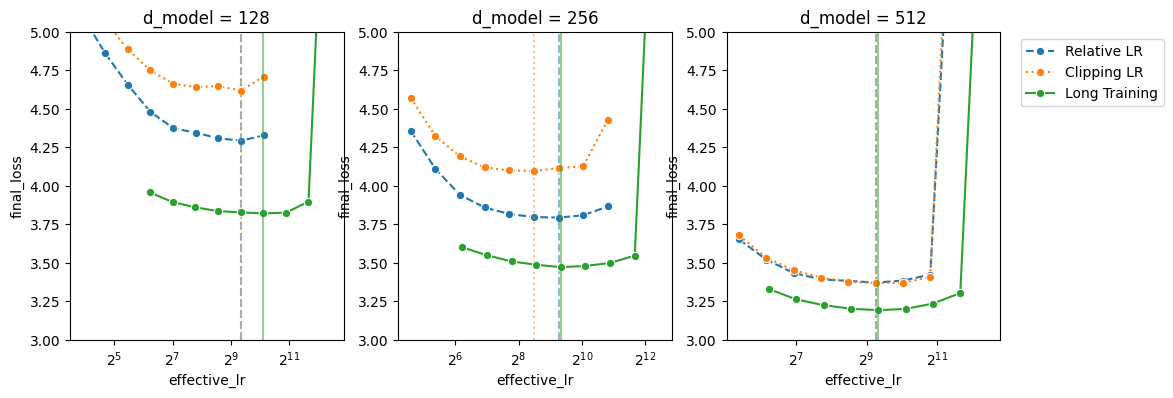

In [49]:
# plot relative versus clipping learning rate loss
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs = axs.flatten()

for i, d_model in enumerate([128, 256, 512]):
    ax = axs[i]
    ax.set_title(f"d_model = {d_model}")
    
    # -------------------------------------------------------------
    # 1. Relative LR Curve + Vertical Line
    # -------------------------------------------------------------
    data_rel = df_best_runs_relative[df_best_runs_relative['d_model'] == d_model]
    sns.lineplot(
        data=data_rel, x='effective_lr', y='final_loss', ax=ax,
        marker='o', linestyle='--', label='Relative LR'
    )
    # Grab the color of the line just plotted and apply it to the vline
    color_rel = ax.lines[-1].get_color()
    
    lr_rel = df_optimal_lrs_relative.loc[df_optimal_lrs_relative['d_model'] == d_model, 'effective_lr'].item()
    ax.axvline(x=lr_rel, linestyle='--', color=color_rel, alpha=0.5)
    
    # -------------------------------------------------------------
    # 2. Clipping LR Curve + Vertical Line
    # -------------------------------------------------------------
    cond_clip = (df_best_runs_not_relative['n_training_tokens'] != 5.84630272e+09) & (df_best_runs_not_relative['d_model'] == d_model)
    sns.lineplot(
        data=df_best_runs_not_relative[cond_clip], x='effective_lr', y='final_loss', ax=ax,
        marker='o', linestyle=':', label='Clipping LR'
    )
    color_clip = ax.lines[-1].get_color()
    
    cond_opt_clip = (df_optimal_lrs_not_relative['d_model'] == d_model) & (df_optimal_lrs_not_relative['n_training_tokens'] != 5.84630272e+09)
    lr_clip = df_optimal_lrs_not_relative.loc[cond_opt_clip, 'effective_lr'].item()
    ax.axvline(x=lr_clip, linestyle=':', color=color_clip, alpha=0.5)
    
    # -------------------------------------------------------------
    # 3. Long Training Curve + Vertical Line
    # -------------------------------------------------------------
    cond_long = (df_best_runs_not_relative['n_training_tokens'] == 5.84630272e+09) & (df_best_runs_not_relative['d_model'] == d_model)
    sns.lineplot(
        data=df_best_runs_not_relative[cond_long], x='effective_lr', y='final_loss', ax=ax,
        marker='o', linestyle='-', label='Long Training'
    )
    color_long = ax.lines[-1].get_color()
    
    cond_opt_long = (df_optimal_lrs_not_relative['d_model'] == d_model) & (df_optimal_lrs_not_relative['n_training_tokens'] == 5.84630272e+09)
    lr_long = df_optimal_lrs_not_relative.loc[cond_opt_long, 'effective_lr'].item()
    ax.axvline(x=lr_long, linestyle='-', color=color_long, alpha=0.5)

    ax.set_xscale('log', base=2)
    ax.set_ylim(3, 5)

    # Clean up legends
    if i == 2:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

